# loading the packages

In [10]:
import matplotlib.pylab as plt
import numpy as np
import h5py
import os
import sys
import data_utils_galaxy_sim as data_utils

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import json
import unittest
import pytorch_lightning as pl
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, TensorDataset

import multiprocessing
import time
import preprocess as prep
import models_edited as models
import utils
from torchvision.utils import save_image


# Loading the galaxy simulation dataset

In [5]:

dirIn = '/lcrc/project/cosmo_ai/nramachandra/Projects/SkyEmu/Data/output_tests_arka/'

# fileIn = dirIn + 'lhc_16384_5_training' + '.txt'  ## Training set N=256
fileIn = dirIn + 'lhc_64_5_test' + '.txt'   ## Test set N=64


# Read image params from the text file
image_params = data_utils.read_input_params(fileIn)
print('Parameter shape (nGal, param_size):', image_params.shape)
column_labels = ['flux', 'radius', 'g1', 'g2', 'psf']
image_params_reordered = image_params[:, [column_labels.index(label) for label in ['radius','g1', 'g2','flux', 'psf']]]
#data_utils.plot_scatter_and_histogram_labeled(image_params, column_labels)

fileIn = dirIn + 'train_16384_5_training' + '.hdf5'  ## Training set N=256
# fileIn = dirIn + 'test_64_5_testing' + '.hdf5' ## Test sey N=64

# Read from the HDF5 file
images = data_utils.read_hdf5_outputs(fileIn)
image_params = data_utils.read_input_params('/lcrc/project/cosmo_ai/nramachandra/Projects/SkyEmu/Data/lhc_16384_5_training.txt')
image_params_reordered = image_params[:, [column_labels.index(label) for label in ['radius','g1', 'g2', 'flux', 'psf']]]
image_params=image_params_reordered
print('Galaxy image shape (nGal, pixel_size, pixel_size): ', np.array(images).shape)



Parameter shape (nGal, param_size): (64, 5)
Galaxy image shape (nGal, pixel_size, pixel_size):  (16384, 33, 33)


# Extract the 'image' and auxiliary data and create the dataloader object

In [8]:

image_list = images 

# Convert to a NumPy array
image_array = np.array(image_list)

# Scale the pixel values between [0, 1] adaptively for each image
min_values = np.min(image_array)#, axis=(1, 2), keepdims=True)
max_values = np.max(image_array)#, axis=(1, 2), keepdims=True)

# Avoid division by zero
#max_values[max_values == min_values] = 1.0

image_array_normalized = (image_array - min_values) / (max_values - min_values)
image_list=image_array_normalized

#scaling the u-array

# Compute the minimum and maximum values for each column
min_values = np.min(image_params, axis=0)
max_values = np.max(image_params, axis=0)

# Perform Min-Max scaling for each column
scaled_image_params = (image_params - min_values) / (max_values - min_values)

#creating the auxiliary
u_list_all=scaled_image_params.tolist()

# Initialize empty lists to store the combined data
enumerated_dataset = []
u_list = []
x_list = []

# Enumerate through the lists and combine them
for j, (u, image) in enumerate(zip( u_list_all, image_list)):
    # Create a dictionary to represent the enumerated dataset
    data_entry = {
        'j': j,
        'u': u,  # Combine the first three lists into 'u'
        'x': image  # Store the image from reshaped_images as 'x'   
    }
    
    # Append the data_entry to the enumerated dataset
    enumerated_dataset.append(data_entry)
    u_list.append(u)
    x_list.append(image)


from torch.utils.data import Dataset, DataLoader
class CustomDataset(Dataset):
    def __init__(self, u_list, x_list, device="cuda"):
        self.u_list = torch.tensor(u_list, dtype=torch.float32, device=device)
        self.x_list = torch.tensor(x_list, dtype=torch.float32, device=device)
    
    def __len__(self):
        return len(self.u_list)
    
    def __getitem__(self, idx):
        sample = {
            'u': self.u_list[idx],
            'x': self.x_list[idx]
        }
        return sample

device = "cuda" if torch.cuda.is_available() else "cpu"

# Create an instance of CustomDataset with CUDA-enabled data
custom_dataset = CustomDataset(u_list, x_list, device=device)

class MyDataModule(pl.LightningDataModule):
    def __init__(self, u_list, x_list, batch_size=64):
        super().__init__()
        self.x_list = x_list
        self.u_list = u_list
        self.batch_size = batch_size
    
    def setup(self, stage=None):
        dataset = CustomDataset(self.u_list, self.x_list)
        n = len(dataset)
        n_train = int(0.7 * n)  # 80% train, 20% validation
        n_val = int(0.2 * n)
        n_test = n - (n_train+n_val)
        self.train_dataset, self.val_dataset, self.test_dataset = torch.utils.data.random_split(dataset, [n_train, n_val, n_test])


# Create an instance of MyDataModule
data_module = MyDataModule(u_list, x_list)
data_module.setup()
# Call train_dataloader on the data_module instance
train_loader = DataLoader(data_module.train_dataset, batch_size=64, shuffle=True) #data_module.train_dataloader(batch_size=256)
val_loader= DataLoader(data_module.val_dataset, batch_size=64, shuffle=True) #data_module.val_dataloader(batch_size=256)
test_loader= DataLoader(data_module.test_dataset, batch_size=64, shuffle=True) #data_module.val_dataloader(batch_size=256)


# Training Aux-VAE



In [11]:

def train(model, device, train_loader, optimizer, epoch, log_interval):
    model.train()
    train_loss = 0
    recon_losses = 0
    kl_diverges = 0
    
    for batch_idx, data in enumerate(train_loader):
        x = data['x'].unsqueeze(1).to(device)
        u = data['u'].to(device)
        batch_size=x.shape[0]
        #x= x.view(batch_size, -1)
        optimizer.zero_grad()
        output, z, mu, logvar = model(x)
        #print('mu:', mu.shape)
        #print('logvar:', logvar.shape)
        loss, recon_loss, kl_diverge = model.loss_log_mse_reduced_cor(output, x, z, u, mu, logvar)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        recon_losses += recon_loss.item()
        kl_diverges += kl_diverge.item()
        
        if batch_idx % log_interval == 0:
            print('{} Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                time.ctime(time.time()), epoch, batch_idx * len(data),
                len(train_loader.dataset), 100. * batch_idx / len(train_loader), loss.item()))
    
    train_loss /= len(train_loader)
    recon_losses /= len(train_loader)
    kl_diverges /= len(train_loader)
    print('Train set Average loss:', train_loss, 'recon_loss', recon_losses, 'kl_diverge', kl_diverges)
    return train_loss, recon_losses, kl_diverges


def test(model, device, test_loader, return_images=0, log_interval=None):
    model.eval()
    test_loss = 0
    
    # two np arrays of images
    original_images = []
    rect_images = []
    
    with torch.no_grad():
        for batch_idx, data in enumerate(test_loader):
            x = data['x'].unsqueeze(1).to(device)
            u = data['u'].to(device)
            batch_size=x.shape[0]
            #x = x.view(batch_size, -1)
            output, z, mu, logvar = model(x)
            loss, recon_loss, kl_diverge = model.loss_log_mse_reduced_cor(output, x, z, u, mu, logvar)
            test_loss += loss.item()
            
            if return_images > 0 and len(original_images) < return_images:
                original_images.append(x[0].cpu())
                rect_images.append(output[0].cpu())
            
            if log_interval is not None and batch_idx % log_interval == 0:
                print('{} Test: [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    time.ctime(time.time()),
                    batch_idx * len(data), len(test_loader.dataset),
                    100. * batch_idx / len(test_loader), loss.item()))
    
    test_loss /= len(test_loader)
    print('Test set Average loss:', test_loss)
    
    if return_images > 0:
        return test_loss, original_images, rect_images
    
    return test_loss


# parameters
INPUT_SIZE=33
BATCH_SIZE = 100
TEST_BATCH_SIZE = 10
EPOCHS = 1000

LATENT_SIZE = 10
LEARNING_RATE = 1e-3

USE_CUDA = True
PRINT_INTERVAL = 100
LOG_PATH = './logs/log.pkl'
MODEL_PATH = './checkpoints/'
COMPARE_PATH = './comparisons/'

use_cuda = USE_CUDA and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print('Using device', device)
print('num cpus:', multiprocessing.cpu_count())

print('latent size:', LATENT_SIZE)
# model = models.BetaVAE(latent_size=LATENT_SIZE).to(device)
model = models.BetaVAE_CNN_aux(input_channels=1,latent_size=LATENT_SIZE, u_idx=[0,1,2,3,4], beta=20, reg_inter=.40, reg_intra=.50).to(device) #(10,10,80)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

if __name__ == "__main__":
    
    start_epoch = model.load_last_model(MODEL_PATH) + 1
    train_losses, test_losses = utils.read_log(LOG_PATH, ([], []))
    train_recon_losses=[]
    train_kl_diverges=[]
    for epoch in range(start_epoch, EPOCHS + 1):
        train_loss, train_recon_loss, train_kl_diverge = train(model, device, train_loader, optimizer, epoch, PRINT_INTERVAL)
        #print("training_loss computation done")
        test_loss, original_images, rect_images = test(model, device, test_loader, return_images=5)
        #print("testing_loss computation done")
        
        if epoch % 100 == 0:  # Save the plots only for epochs divisible by 20
            # Create a single plot with two rows for original and reconstructed images
            fig, axs = plt.subplots(2, len(original_images), figsize=(15, 8))
            
            for i in range(len(original_images)):
                im0 = axs[0, i].imshow(original_images[i].view(INPUT_SIZE, INPUT_SIZE), cmap='viridis')
                axs[0, i].set_title("Original Image")
                axs[0, i].axis('off')
                fig.colorbar(im0, ax=axs[0, i], orientation='horizontal')
                
                im1 = axs[1, i].imshow(rect_images[i].view(INPUT_SIZE, INPUT_SIZE), cmap='viridis')
                axs[1, i].set_title("Reconstructed Image")
                axs[1, i].axis('off')
                fig.colorbar(im1, ax=axs[1, i], orientation='horizontal')
            
            plt.tight_layout()
            plt.savefig(COMPARE_PATH + f'{epoch}_image_plots.png', bbox_inches='tight')
            plt.close()
        
        train_losses.append((epoch, train_loss))
        train_recon_losses.append(train_recon_loss)
        train_kl_diverges.append(train_kl_diverge)
        test_losses.append((epoch, test_loss))
        utils.write_log(LOG_PATH, (train_losses, test_losses))
        
        model.save_model(MODEL_PATH + '%03d.pt' % epoch)



Using device cuda
num cpus: 256
latent size: 10
Tue May 21 15:00:59 2024 Train Epoch: 1 [0/11468 (0%)]	Loss: 45.052277
Tue May 21 15:01:01 2024 Train Epoch: 1 [200/11468 (56%)]	Loss: 16.820456
Train set Average loss: 21.77783438894484 recon_loss 14.595254034466214 kl_diverge 0.01736635636383047
Test set Average loss: 16.259504831754246
Saved ./checkpoints/001.pt

Tue May 21 15:01:03 2024 Train Epoch: 2 [0/11468 (0%)]	Loss: 16.473858
Tue May 21 15:01:04 2024 Train Epoch: 2 [200/11468 (56%)]	Loss: 15.117660
Train set Average loss: 14.897863223817613 recon_loss 8.406999667485556 kl_diverge 0.011781819723546505
Test set Average loss: 15.027932790609507
Saved ./checkpoints/002.pt

Tue May 21 15:01:06 2024 Train Epoch: 3 [0/11468 (0%)]	Loss: 13.918369
Tue May 21 15:01:07 2024 Train Epoch: 3 [200/11468 (56%)]	Loss: 14.507542
Train set Average loss: 14.663907199435764 recon_loss 8.20765261914995 kl_diverge 0.009865945357725852
Test set Average loss: 14.548917513627272
Saved ./checkpoints/003.p

# Visualizing MSE vs KL

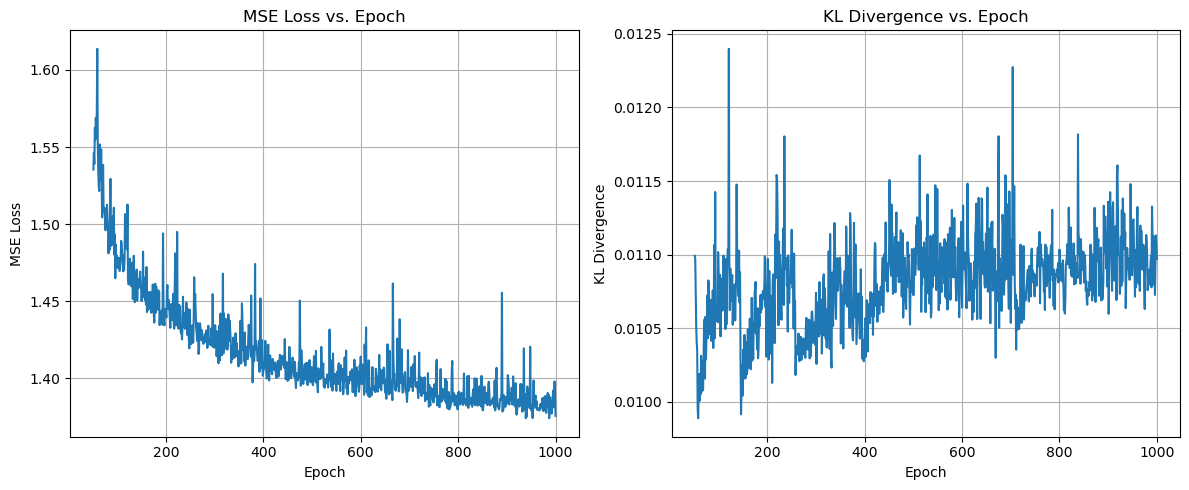

In [12]:

# Create an array of epochs
epochs = np.arange(EPOCHS) + 1

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the MSE loss
axes[0].plot(epochs[50:], train_recon_losses[50:])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('MSE Loss vs. Epoch')
axes[0].grid(True)

# Plot the KL divergence
axes[1].plot(epochs[50:], train_kl_diverges[50:])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].set_title('KL Divergence vs. Epoch')
axes[1].grid(True)

# Adjust the spacing between subplots
plt.tight_layout()
plt.show()



torch.Size([10000, 10])


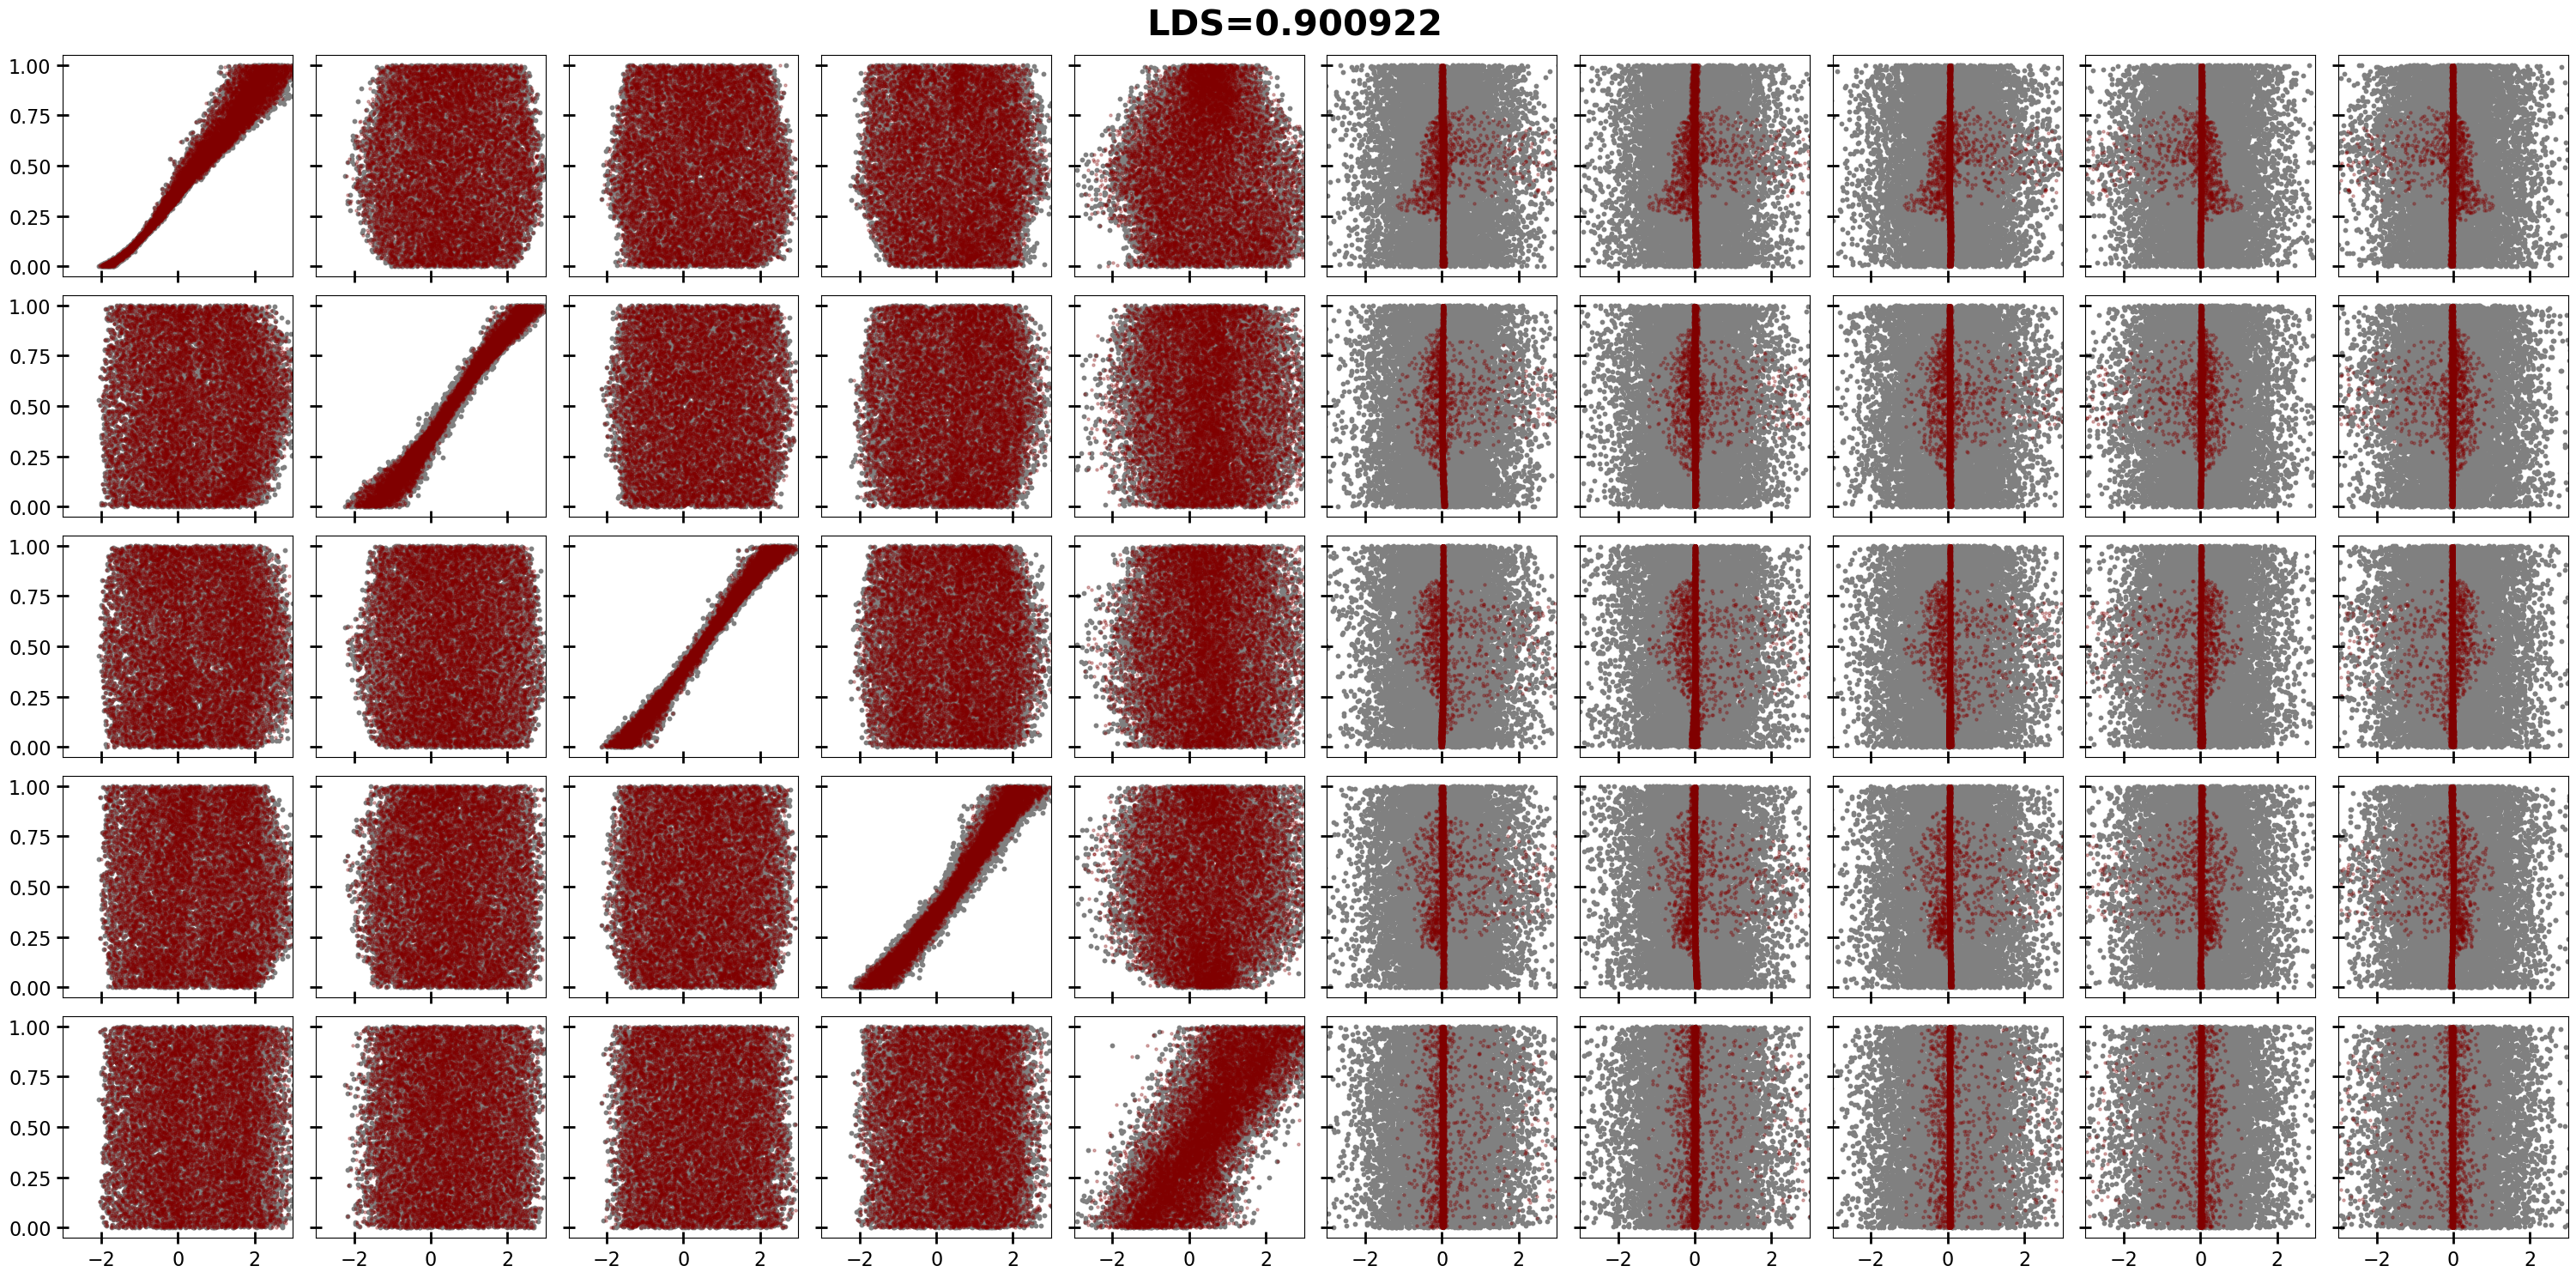

In [13]:

model.eval()

for batch_idx, data in enumerate(DataLoader(data_module.train_dataset, batch_size=10000, shuffle=True)):
    x = data['x'].unsqueeze(1).to(device)
    u = data['u'].to(device) #shape=(10000,2)
    batch_size=x.shape[0]
    #x = x.view(batch_size, -1)
    output,z, mu, logvar = model(x) #shape of mu= (10000,4)
    print(mu.shape)
    if batch_idx==0:
        break



Z_numpy=z.cpu().detach().numpy()
cor_reduced=torch.abs(torch.corrcoef(torch.cat((z, u[:,[0,1,2]]),axis=1).T))[:(mu.shape[1]),(mu.shape[1]):]
m_reduced= torch.sum(torch.max(cor_reduced, axis=0).values/torch.sum(cor_reduced, axis=0))/3
# Extract the first two dimensions of mu and u
mu_10d = mu[:,:10].cpu().detach().numpy()
#sigma_2d=logvar[:,:5].exp().cpu().detach().numpy()
u_5d = u.cpu().detach().numpy()

# Define the dimensions for the subplots
num_rows = 5
num_cols = 10
# Create a 5x5 matrix of scatter plots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(30, 15), sharex=True, sharey=True)

# Iterate through each pair of dimensions
for i in range(num_rows):
    for j in range(num_cols):
        # Scatter plot for cross-correlations (off-diagonal)
        axes[i, j].scatter(Z_numpy[:, j], u_5d[:, i],  alpha=1, s=10, color='grey') #008080 #000080
        axes[i, j].scatter(mu_10d[:, j], u_5d[:, i],  alpha=0.3, s=5, color='#800000') #FF7F50 #800000
        # Set x-axis limits
        axes[i, j].set_xlim(-3, 3)
        # Set x-axis tick parameters
        axes[i, j].tick_params(axis='x', which='both', labelsize=16, width=2, length=10, direction='inout', colors='black', pad=5)
        # Set y-axis tick parameters
        axes[i, j].tick_params(axis='y', which='both', labelsize=16, width=2, length=10, direction='inout', colors='black', pad=5)

# Add a title to the entire figure
fig.suptitle('LDS=' + str(m_reduced.detach().cpu().numpy()), x=0.5, y=0.99, ha='center', fontsize=30, fontweight='bold')

plt.tight_layout()
plt.show()


# t-SNE visualization

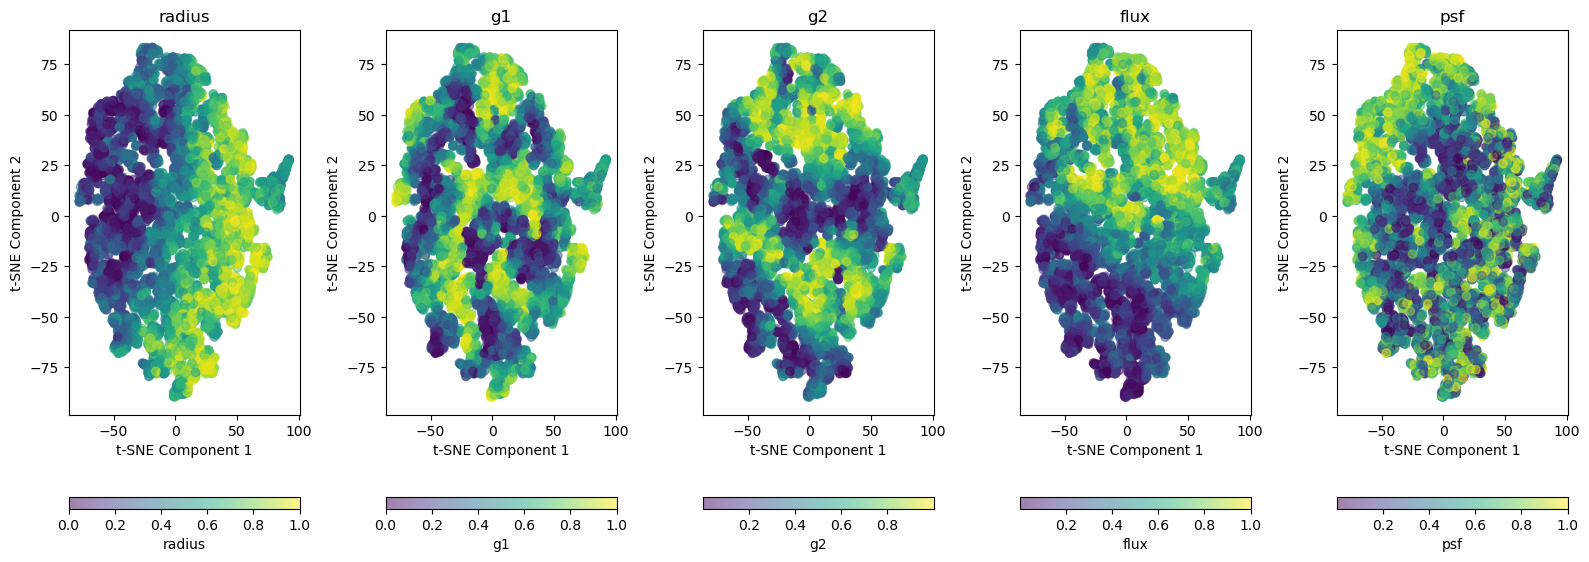

In [17]:

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Transform mu using t-SNE
tsne = TSNE(n_components=2, random_state=41)
mu_2d = tsne.fit_transform(mu.cpu().detach().numpy())#mu_10d)
row_names = [ 'radius', 'g1', 'g2', 'flux', 'psf']
# Plot t-SNE with respect to each column in u_5d side by side
plt.figure(figsize=(16, 6))  # Adjust the figure size as needed

# Loop through each column in u_5d
for i in range(5):
    plt.subplot(1, 5, i+1)  # Create subplots in a single row
    plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=u_5d[:, i], cmap='viridis', alpha=0.5)
    plt.colorbar(label=row_names[i], orientation='horizontal' )  # Add colorbar with label
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title(row_names[i])

plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()


# Reconstruction

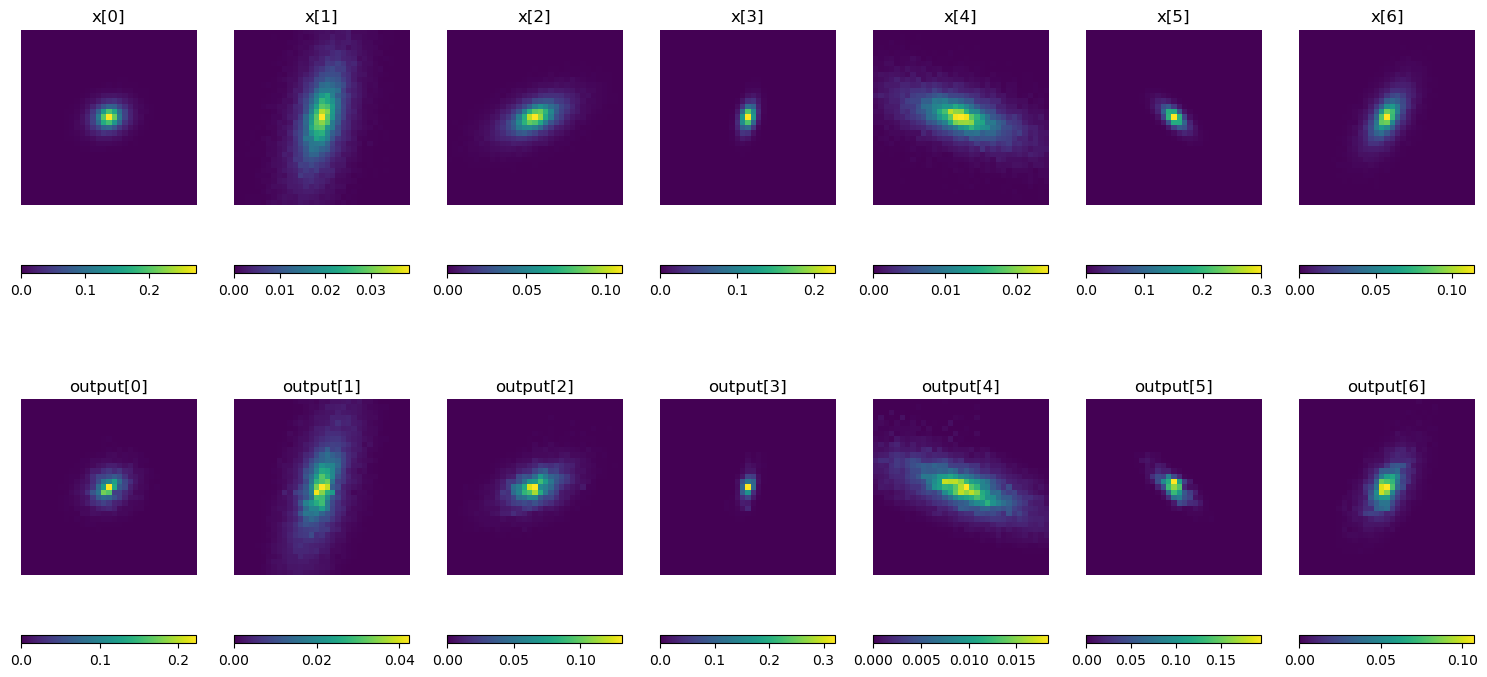

In [19]:

x_numpy = x.cpu().detach().numpy().reshape(10000, 33, 33)
output_numpy = output.cpu().detach().numpy().reshape(10000, 33, 33)


# Create subplots with 2 rows and 7 columns
fig, axs = plt.subplots(2, 7, figsize=(15, 8))

# Plot x in the first row and add variance to the caption
for i in range(7):
    variance_x = np.var(x_numpy[i]) * 1000
    im0 = axs[0, i].imshow(x_numpy[i], cmap='viridis')
    axs[0, i].set_title(f'x[{i}]')
    axs[0, i].axis('off')
    fig.colorbar(im0, ax=axs[0, i], orientation='horizontal')

# Plot output in the second row and add variance to the caption
for i in range(7):
    variance_output = np.var(output_numpy[i]) * 1000
    im1 = axs[1, i].imshow(output_numpy[i], cmap='viridis')
    axs[1, i].set_title(f'output[{i}]')
    axs[1, i].axis('off')
    fig.colorbar(im1, ax=axs[1, i], orientation='horizontal')

plt.tight_layout()
plt.show()


# Latent space traversal

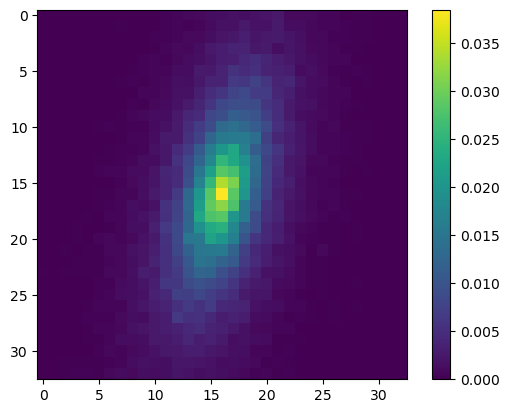

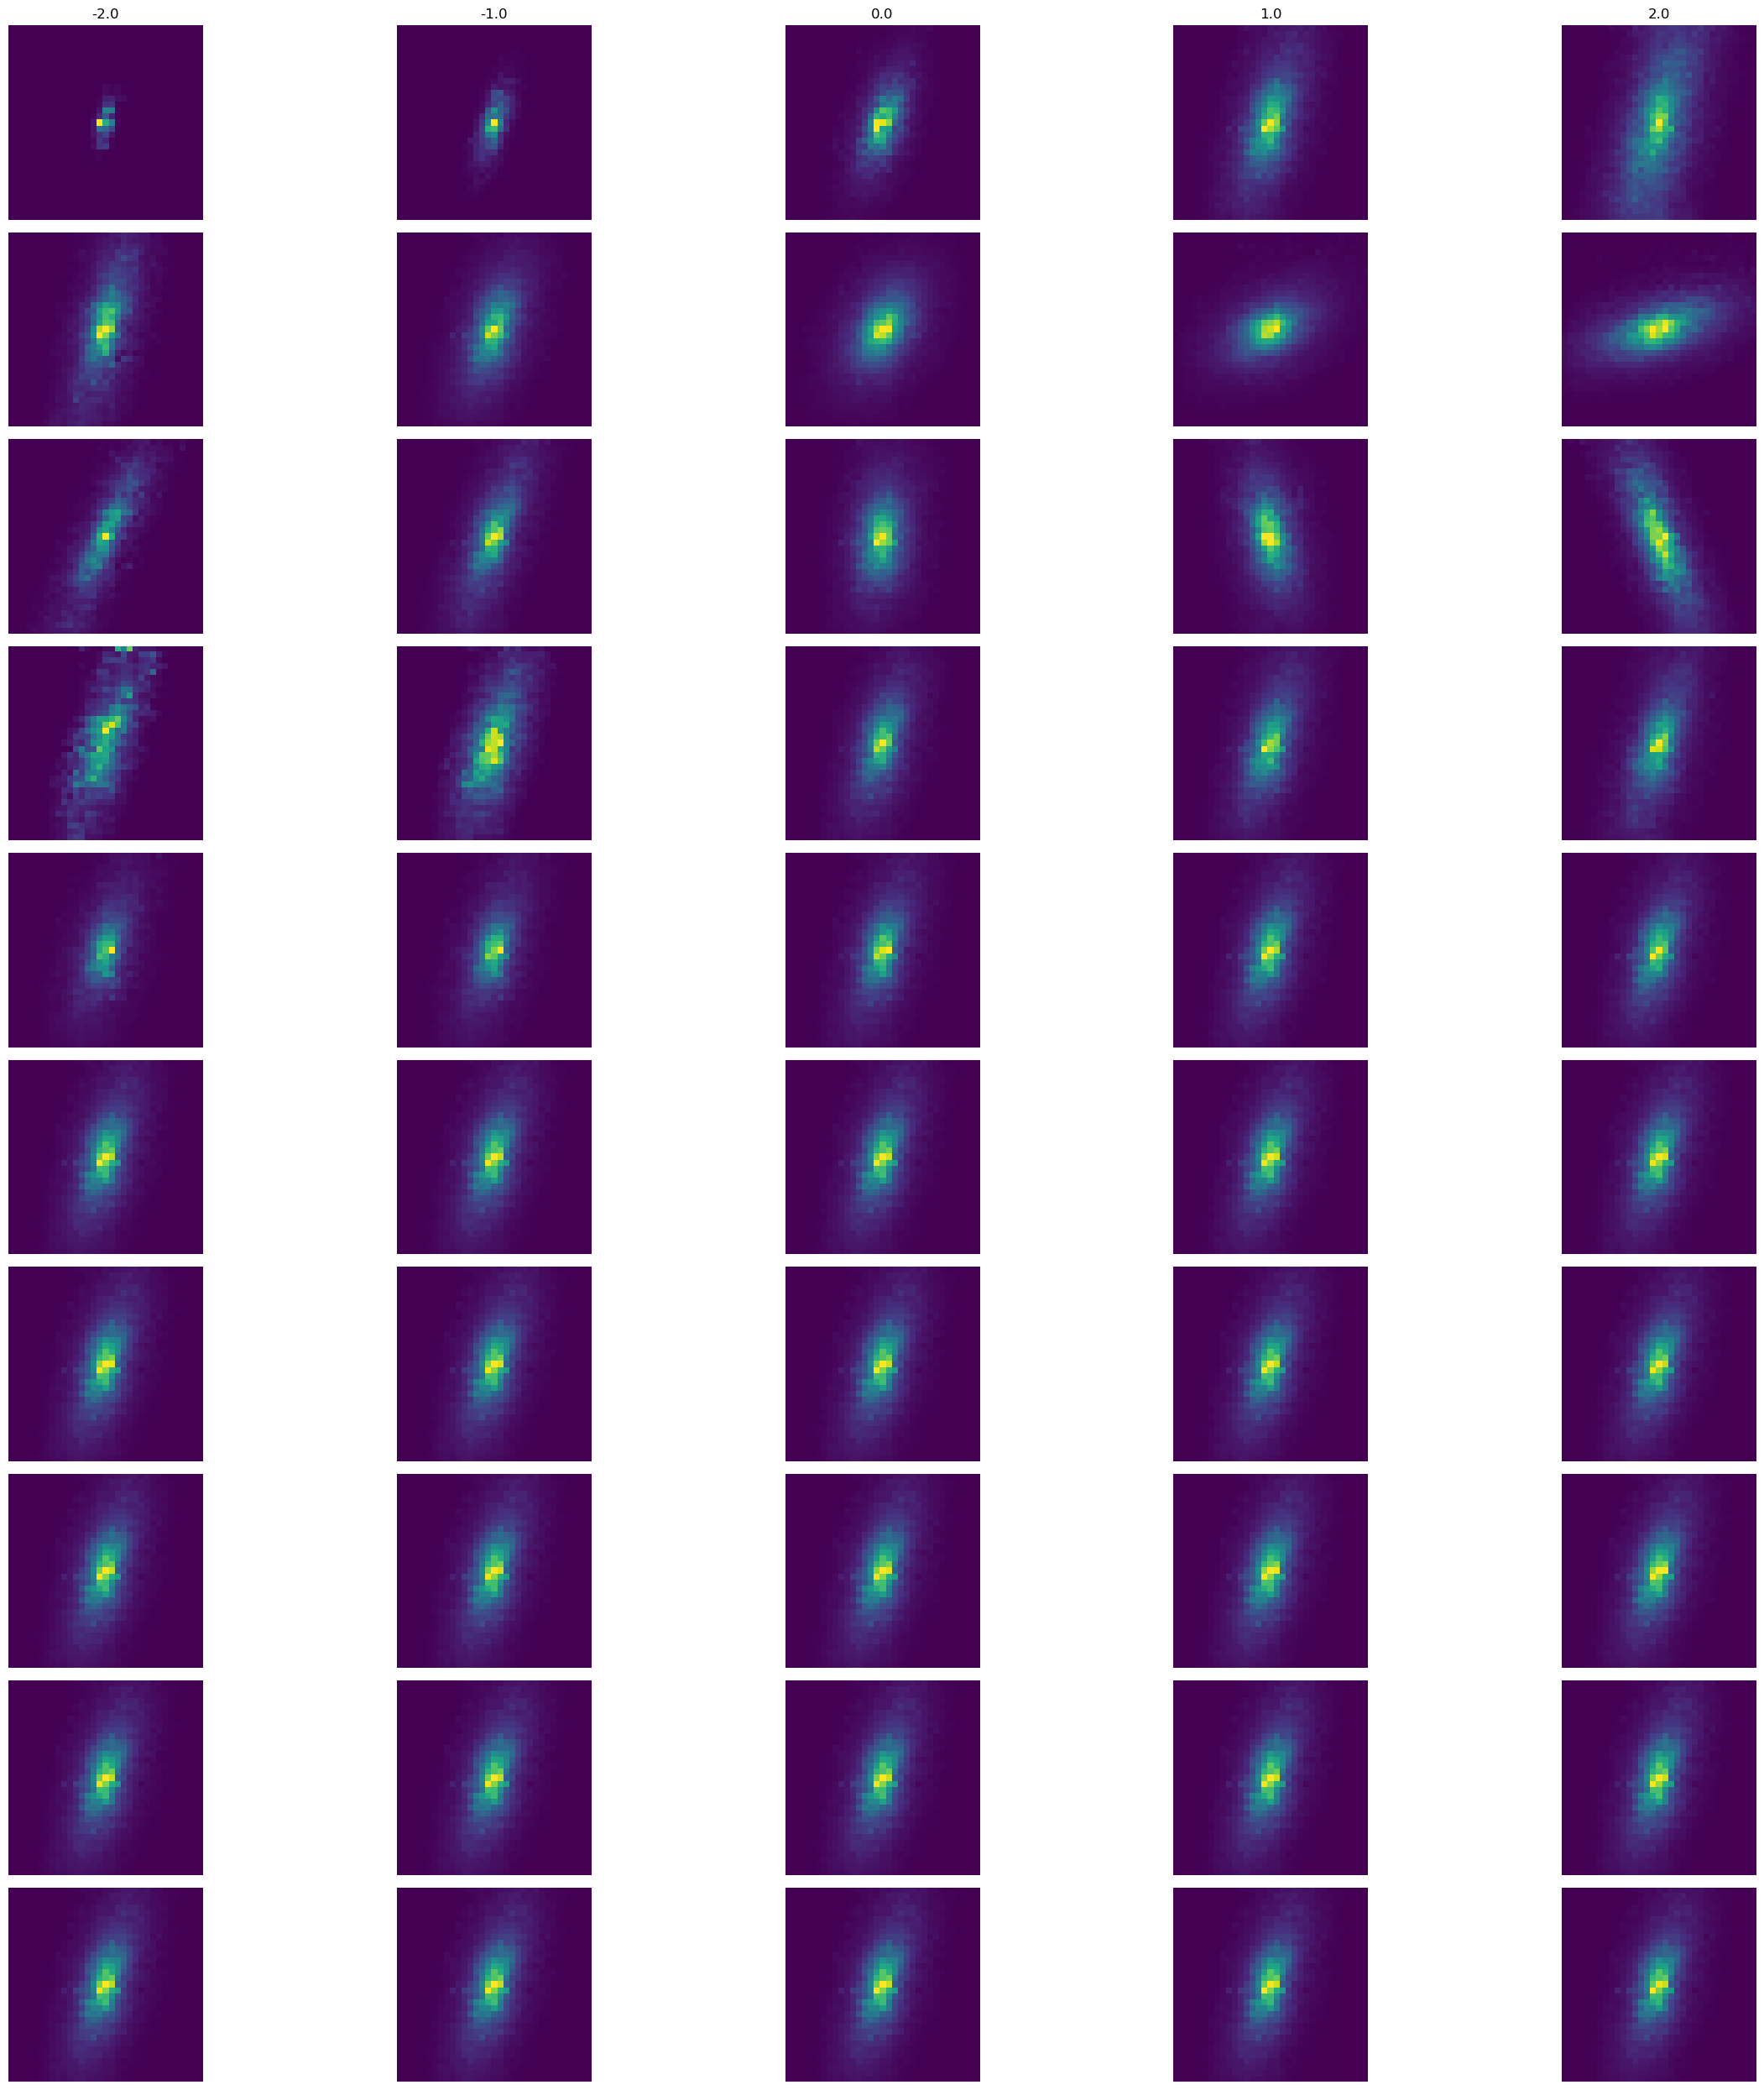

In [26]:

# Get the first row of the tensor
image_id=1
first_row = x[image_id].detach().cpu().numpy().reshape(-1,1)
image = first_row.reshape(33, 33)

# Plot the image
plt.imshow(image, cmap='viridis')  # Choose a colormap as per your preference
plt.colorbar()  # Add color bar for reference
plt.show()
# Define the fixed values for the last 5 latent variables

# Define the fixed values for the last 5 latent variables
fixed_latent_vars = z[image_id].clone().repeat(5, 1)  # Repeat the same values 5 times

# Move fixed_latent_vars to the same device as u
device = mu.device
fixed_latent_vars = fixed_latent_vars.to(device)

# Add one last column with a single random value repeated 5 times
#random_value = torch.rand(5).to(device)  # Generate a single random value and move it to the same device as fixed_latent_vars
#last_column = random_value.repeat(5, 1)  # Repeat the random value 5 times in the last column
#fixed_latent_vars = torch.cat((fixed_latent_vars, last_column), dim=1)

# Create a figure with a 5x10 grid of subplots
fig, axs = plt.subplots(10, 5, figsize=(25, 25))

# Define row names
#row_names = [ 'radius', 'g1', 'g2', 'flux', 'psf']
row_names = [ 'radius', 'g1', 'g2', 'flux', 'psf']

# Create a common colorbar
#cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Adjust the position and size as needed

# Loop through the first 5 latent variables
for i in range(10):
    # Generate a range of values for the i-th latent variable from 0.1 to 1
    latent_var_values = torch.linspace(-2, 2, 5) #torch.linspace(0.1, 1, 5)
    
    # Repeat the fixed latent variables for this dimension
    latent_vars = fixed_latent_vars.clone()
    latent_vars[:, i] = latent_var_values
    
    # Generate images using the modified latent variables (latent_vars)
    #generated_images = model.decode(latent_vars.to(device)).cpu().detach().numpy()
    generated_images = model.decode(latent_vars.to(device)).cpu().detach().numpy()
    # Loop through the 10 generated images for this latent variable
    for j in range(5):
        ax = axs[i, j]
        im = ax.imshow(generated_images[j].reshape(33, 33), cmap='viridis')
        #im = ax.plot(generated_images[j].reshape(33, 33))
        #if j==0:
            #ax.set_xlabel(row_names[i])
            #ax.set_ylabel(row_names[i])
        ax.axis('off')

# Set column names as 0.1, 0.2, ..., 0.9, 1
for j in range(5):
    axs[0, j].set_title(f'{latent_var_values[j]}') #(f'{0.1 + (2*j) * 0.1:.1f}')

for j in range(5):
    axs[j, 0].set_ylabel(f'{row_names[j]}') #(f'{0.1 + (2*j) * 0.1:.1f}')
 

# Add a single colorbar for all subplots
#fig.colorbar(im, cax=cbar_ax)

# Adjust spacing between subplots
plt.tight_layout()
plt.show()